In [1]:
import rtoml
import os
from scipy.io import loadmat
from scipy.signal import savgol_filter
import numpy as np
from pylottone import mrdhelper

import pylottone as pt
from pylottone import extract_raw_pt
import matplotlib.pyplot as plt

from pylottone.triggering import pt_ecg_jitter, extract_triggers
%matplotlib widget


In [2]:
cfg_ = 'configs/config_vol1321.toml'
with open(cfg_, 'r') as cf:
    cfg = rtoml.load(cf)

## Cardiac modulation percentage

In [3]:
from typing import Literal

def modulation_percentage(signal: np.ndarray, signal_mean: np.ndarray, mode: Literal['extent', 'std', 'percentile'] = 'extent') -> float:
    """Calculate the modulation percentage of a signal.

    Args:
        signal (np.ndarray): Filtered input signal.
        signal_mean (np.ndarray): Mean of the raw pilot tone signal.
    Returns:
        modulation_pct (float): Modulation percentage.
    """
    if mode == 'extent':
        modulation = np.max(signal, axis=0) - np.min(signal, axis=0)
    elif mode == 'std':
        modulation = np.std(signal, axis=0)
    elif mode == 'percentile':
        modulation = np.percentile(signal, 95, axis=0) - np.percentile(signal, 5, axis=0)
    modulation_pct = (modulation / signal_mean) * 100
    return modulation_pct

# print("Cardiac modulation percentage: ", modulation_percentage(pt_cardiac_freqs, pt_raw.mean(axis=0), mode='percentile'))

# Load waveforms

In [64]:
from pylottone.signal import designbp_tukeyfilt_freq, apply_filter_freq
# List all files in the directory ending with .npz


npz_files = [f for f in os.listdir("/server/home/btasdelen/MRI_DATA/pilottone/phantom0453_20251204/") if f.endswith(".npz")]

f_samp = None
filt_bp_resp = None
filt_bp_cardiac = None
m_pctg = []
n_pt_samples = 0
pt_wfs = {}
cryst_list = []
for npz_file in npz_files:
    print(f"Loading {npz_file}...")
    ids = "_".join(npz_file.split('_')[6:-2])
    if '24.05MHz' in npz_file:
        print(f"IDs: {ids}")
        cryst_list.append(ids.split('MHz')[-1])
        with np.load(os.path.join("/server/home/btasdelen/MRI_DATA/pilottone/phantom0453_20251204/", npz_file)) as data:
            pt_wfs[ids] = {}
            for key in data.files:
                pt_wfs[ids][key] = data[key]

        if f_samp is None:
            dt_pt = pt_wfs[ids]['time_pt'][1] - pt_wfs[ids]['time_pt'][0]
            f_samp = 1 / dt_pt
            n_pt_samples = len(pt_wfs[ids]['time_pt'])
            filt_bp_resp = designbp_tukeyfilt_freq(cfg['pilottone']['respiratory']['freq_start'], cfg['pilottone']['respiratory']['freq_stop'], f_samp, n_pt_samples)
            filt_bp_cardiac = designbp_tukeyfilt_freq(cfg['pilottone']['cardiac']['freq_start'], 20, f_samp, n_pt_samples)

        pt_wfs[ids]['pt_raw_filt'] = savgol_filter(np.abs(pt_wfs[ids]['pt_raw']), 81, 3, axis=0)
        pt_wfs[ids]['pt_respiratory_freqs'] = apply_filter_freq(pt_wfs[ids]['pt_raw_filt'], filt_bp_resp, 'symmetric')
        pt_wfs[ids]['pt_cardiac_freqs'] = apply_filter_freq(pt_wfs[ids]['pt_raw_filt'], filt_bp_cardiac, 'symmetric')

        m_pctg.append(modulation_percentage(pt_wfs[ids]['pt_cardiac_freqs'], np.abs(pt_wfs[ids]['pt_raw']).mean(axis=0), mode='percentile'))
        print("Cardiac modulation percentage: ", m_pctg[-1])
m_pctg = np.array(m_pctg)
# pt_wfs = np.load("/server/home/btasdelen/MRI_DATA/pilottone/vol1321_20250903/meas_MID01372_FID26761_pulseq2D_fire_spiralga_RH_h2_AH_400mV_24MHz_ptwaveforms.npz")

Loading meas_MID01458_FID35469_pulseq2D_fire_spiralga_ch1loop24MHz_ch2mpl24_05MHz_distilled_ptwaveforms_24.0MHz.npz...
Loading meas_MID01464_FID35475_pulseq2D_fire_spiralga_ch1loop24MHz_ch2mpl24_05MHz_2cryst_ptwaveforms_24.05MHz.npz...
IDs: ch1loop24MHz_ch2mpl24_05MHz_2cryst
Cardiac modulation percentage:  [0.65875697 0.56463026 0.61797063 0.75427803 0.6991056  0.75411191
 0.61979615 0.35697054 0.6916124  0.66447395 0.83377598 0.75834169
 0.66433564 0.65821881 0.8066881  0.86738347 0.85042849 0.66439679]
Loading meas_MID01463_FID35474_pulseq2D_fire_spiralga_ch1loop24MHz_ch2mpl24_05MHz_1_5cryst_ptwaveforms_24.0MHz.npz...
Loading meas_MID01461_FID35472_pulseq2D_fire_spiralga_ch1loop24MHz_ch2mpl24_05MHz_0_9cryst_ptwaveforms_24.05MHz.npz...
IDs: ch1loop24MHz_ch2mpl24_05MHz_0_9cryst
Cardiac modulation percentage:  [0.8978685  1.09675534 0.84416025 0.87085043 0.88236296 0.96451534
 0.78930812 0.33173954 0.92375109 0.86529376 1.10926188 0.88189384
 0.88454661 0.89061847 0.95224868 1.02729688 

Cardiac modulation percentage:  [0.67265839 0.67376419 0.63653214 0.74025129 0.6975509  0.75626288
 0.67207426 0.33213676 0.70416687 0.67080772 0.83082927 0.72937406
 0.68128703 0.69068582 0.78999459 0.85704833 1.06140894 0.67077723]
Loading meas_MID01462_FID35473_pulseq2D_fire_spiralga_ch1loop24MHz_ch2mpl24_05MHz_1_0cryst_ptwaveforms_24.05MHz.npz...
IDs: ch1loop24MHz_ch2mpl24_05MHz_1_0cryst
Cardiac modulation percentage:  [0.77909945 0.97756409 0.73606195 0.79952581 0.78026516 0.84405779
 0.70622342 0.33325385 0.79515578 0.76387389 0.94641718 0.80174865
 0.77718857 0.76696107 0.8664918  0.9465598  1.00797915 0.7621801 ]


In [66]:
print(cryst_list)
# order = [0, 5, 2, 3, 1, 4] # for 24.0MHz
order = [3, 2, 1, 5, 4, 0] # for 24.05MHz
print([cryst_list[i] for i in order])
print(m_pctg.shape)
sel_chs = m_pctg.max(axis=0) > 1.1
print(sel_chs)

['_2cryst', '_0_9cryst', '_0_5cryst', '_distilled', '_1_5cryst', '_1_0cryst']
['_distilled', '_0_5cryst', '_0_9cryst', '_1_0cryst', '_1_5cryst', '_2cryst']
(6, 18)
[False  True False False False False False False False False  True False
 False False False False  True False]


/server/home/btasdelen/workspace/PyPilotTone/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


Text(0, 0.5, 'Cardiac Modulation Percentage (%)')

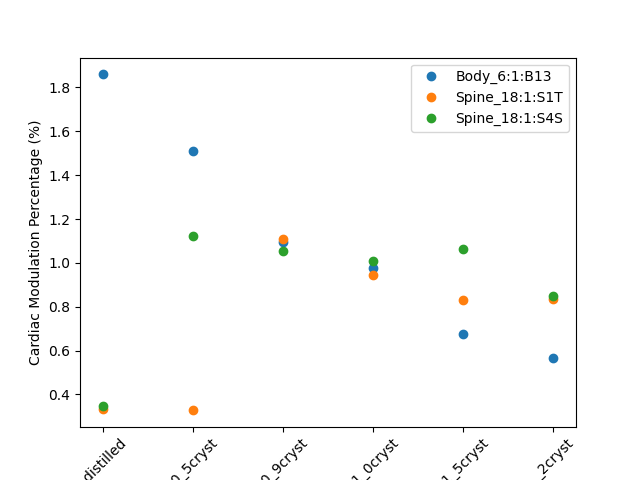

In [67]:
coil_names = pt_wfs[ids]['coil_name']
fig, ax = plt.subplots()
ax.plot((m_pctg[order, :])[:, sel_chs], marker='o', linestyle='None')
ax.set_xticks(range(len(cryst_list)))
ax.set_xticklabels([cryst_list[i] for i in order], rotation=45)
plt.legend(coil_names[sel_chs])
plt.xlabel('Measurement Index')
plt.ylabel('Cardiac Modulation Percentage (%)')


In [ ]:
for id in pt_wfs.keys():
    if 'h3_' in id:
        print(f"IDs: {id}")
        print("Cardiac modulation percentage: ", modulation_percentage(pt_wfs[id]['pt_cardiac_freqs'], np.abs(pt_wfs[id]['pt_raw']).mean(axis=0), mode='std')[[0,1,5,6,13]])
        print("Rssq cardiac modulation percentage: ", modulation_percentage(pt.signal.rssq(pt_wfs[id]['pt_cardiac_freqs'], axis=0), pt.signal.rssq(pt_wfs[id]['pt_raw'], axis=1).mean(axis=0), mode='std'))

    

IDs: RF_h3_AV_100mV
Cardiac modulation percentage:  [0.71197646 0.05833466 0.11116444 0.24931528 0.44225546]
Rssq cardiac modulation percentage:  0.9157070122212951
IDs: RH_h3_AV_400mV
Cardiac modulation percentage:  [1.4865895  0.06630825 0.12191733 0.10282767 0.28088078]
Rssq cardiac modulation percentage:  1.0032885903778725
IDs: CH_h3_AH_200mV
Cardiac modulation percentage:  [0.53392999 0.06930731 0.15507245 0.28065936 0.27689554]
Rssq cardiac modulation percentage:  1.2475644152094203
IDs: CH_h3_AV_200mV
Cardiac modulation percentage:  [1.0641719  0.07610135 0.15386449 0.15952528 0.40837418]
Rssq cardiac modulation percentage:  1.1550822571015509
IDs: CF_h3_AV_400mV
Cardiac modulation percentage:  [0.76083988 0.06000864 0.11001907 0.1792497  0.28010061]
Rssq cardiac modulation percentage:  0.9188691654494124
IDs: CHH_h3_AH_400mV
Cardiac modulation percentage:  [0.71219895 0.063054   0.13596248 0.5620409  0.34651022]
Rssq cardiac modulation percentage:  0.9457213045001401
IDs: CF_h

In [46]:
np.abs(pt_wfs[id]['pt_raw']).shape

(10080, 15)

In [95]:
pt_wfs[id]['accept_list_cardiac']


array([ 5,  0,  1,  8,  9, 12, 13])

In [ ]:
from pylottone.sobi import sobi
from pylottone.pt import pick_cardiac_source

mod_percentages  = []
mean_mod_percentages  = []
max_mod_percentages  = []
median_mod_percentages  = []
row_var = []
col_var = []
volt_var = []
orient_var = []

for id in pt_wfs.keys():
    # if 'AV_' in id:
    # mod_percentages.append(modulation_percentage(pt.signal.rssq(pt_wfs[id]['pt_cardiac_freqs'][:,[0,1,5,6,13]], axis=0), pt.signal.rssq(pt_wfs[id]['pt_raw'][:,[0,1,5,6,13]], axis=1).mean(axis=0), mode='std'))
    # pt_raw_reduced = pt_wfs[id]['pt_raw'][:,pt_wfs[id]['accept_list_cardiac']]
    accept_list_cardiac,_,_ = pt.pickcoilsbycorr(pt_wfs[id]['pt_cardiac_freqs'], 0, 0.8)
    # print(f"Number or accepted coils: {len(accept_list_cardiac)}")
    pt_cardiac_sobi, Ucard, Vcard = sobi(pt_wfs[id]['pt_cardiac_freqs'][:, accept_list_cardiac].T, num_lags=600)
    idxs, envstds = pick_cardiac_source(pt_cardiac_sobi.T, f_samp)
    sel_src = idxs[np.argmin(envstds)]
    pt_cardiac_bp = (Ucard[:,sel_src][:,None])@(pt_cardiac_sobi[sel_src,:][None,:])
    # mod_percentages.append(modulation_percentage(pt_wfs[id]['S'][:,1], np.abs(pt_raw_reduced[:,1]).mean(axis=0), mode='std'))
    mpcg = modulation_percentage(pt_cardiac_bp.T, np.abs(pt_wfs[id]['pt_raw'][:,accept_list_cardiac]).mean(axis=0), mode='std')
    # print(f'{np.abs(pt_wfs[id]['pt_raw'][:,accept_list_cardiac]).mean(axis=0)}')

    mod_percentages.append(mpcg)
    mean_mod_percentages.append(np.mean(mpcg))
    max_mod_percentages.append(np.max(mpcg))
    median_mod_percentages.append(np.median(mpcg))
    row_var.append(id.split('_')[0])
    col_var.append(id.split('_')[1])
    volt_var.append(id.split('_')[3])
    orient_var.append(id.split('_')[2])

sindx = sorted(range(len(mod_percentages)), key=lambda k: max_mod_percentages[k], reverse=True)

# print(np.array(row_var)[sindx])
# print(np.array(col_var)[sindx])
# print(np.array(max_mod_percentages)[sindx])
# print(np.array(mean_mod_percentages)[sindx])
# print(np.array(median_mod_percentages)[sindx])
# print(np.array(volt_var)[sindx])
# print(np.array(orient_var)[sindx])

# Print these as a vertical table

print("Row\tMax Mod %\tMean Mod %\tMedian Mod %\tCol\tVolt\tOrient")
for i in sindx:
    print(f"{row_var[i]}\t{max_mod_percentages[i]:.2f}\t{mean_mod_percentages[i]:.2f}\t{median_mod_percentages[i]:.2f}\t{col_var[i]}\t{volt_var[i]}\t{orient_var[i]}")

# print(f"Mean modulation percentage: {np.mean(mod_percentages):.2f} %")

Number or accepted coils: 7
Number or accepted coils: 6
Number or accepted coils: 3
Number or accepted coils: 7
Number or accepted coils: 4
Number or accepted coils: 5
Number or accepted coils: 4
Number or accepted coils: 3
Number or accepted coils: 7
Number or accepted coils: 3
Number or accepted coils: 6
Number or accepted coils: 5
Number or accepted coils: 3
Number or accepted coils: 7
Number or accepted coils: 7
Number or accepted coils: 6
Number or accepted coils: 6
Number or accepted coils: 6
Number or accepted coils: 2
Number or accepted coils: 7
Number or accepted coils: 2
Number or accepted coils: 4
Number or accepted coils: 2
Number or accepted coils: 7
['RH' 'RH' 'RH' 'RH' 'CHH' 'RH' 'RH' 'CHH' 'CH' 'CH' 'CH' 'CF' 'CF' 'RF'
 'CF' 'CHH' 'CF' 'CF' 'CHH' 'CF' 'CH' 'RF' 'CH' 'CH']
['h3' 'h3' 'h2' 'h1' 'h2' 'h2' 'h1' 'h1' 'h2' 'h3' 'h2' 'h1' 'h1' 'h3'
 'h2' 'h2' 'h3' 'h2' 'h3' 'h3' 'h1' 'h3' 'h1' 'h3']
[1.57206399 1.47245317 1.42366521 1.33876677 1.32921156 1.31235547
 1.29304169

/server/home/btasdelen/.cache/uv/archive-v0/dpYNSd5ZEP8l-RMrVAgfM/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


(<Figure size 1000x1000 with 1 Axes>,
 array([<Axes: xlabel='Time [s]'>], dtype=object))

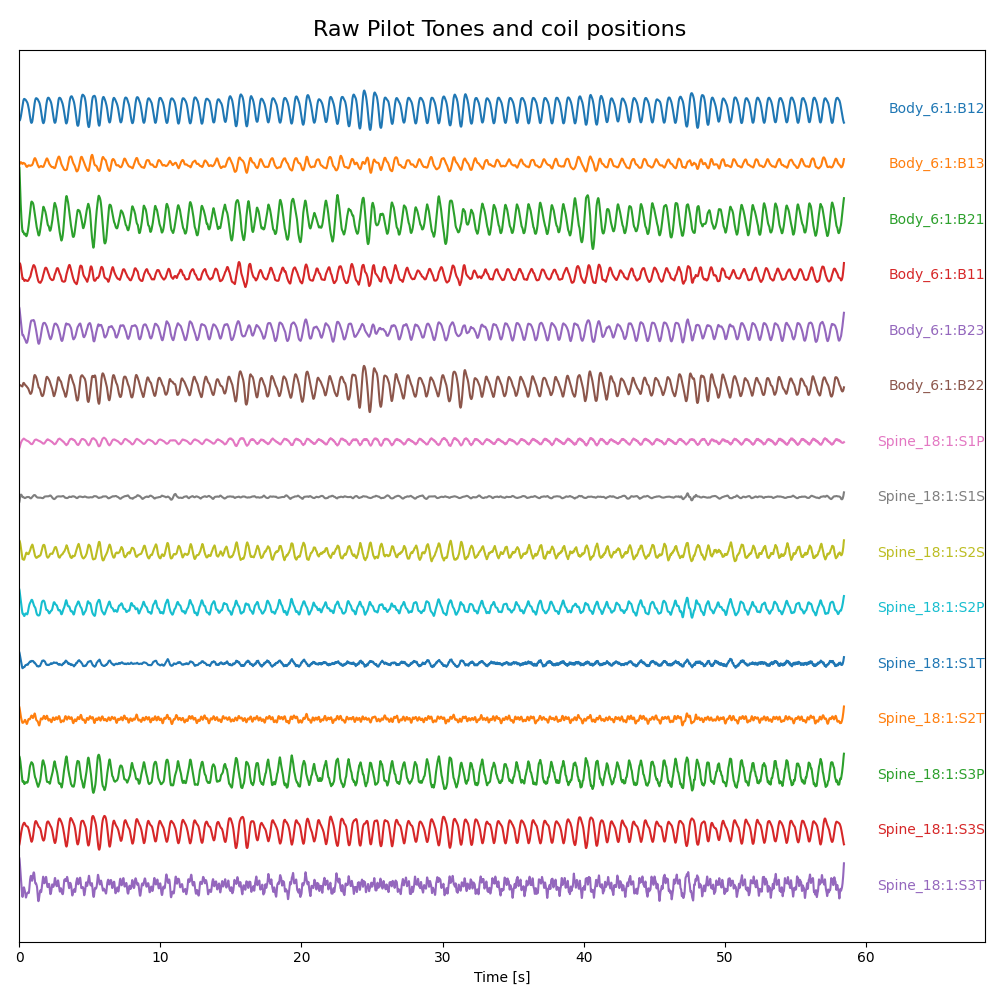

In [41]:
plot_rawpt(pt_wfs[id]['pt_cardiac_freqs'], coil_name, pt_wfs[id]['time_pt'], sort=False, drawcoils=False)

/server/home/btasdelen/.cache/uv/archive-v0/dpYNSd5ZEP8l-RMrVAgfM/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


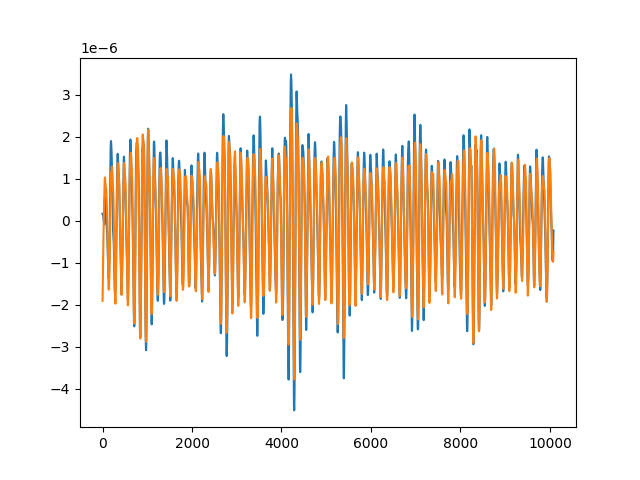

In [ ]:
plt.figure()
plt.plot(pt_wfs[ids]['pt_cardiac_freqs'][:,5])
plt.plot(pt_wfs[ids]['S'][:,0])
plt.show()

# Check mod percentage across amplitude sweep.

In [34]:
pt_wfs

{'meas_MID00298_FID24245_pulseq2D_fire_spiralga_200mV_24MHz_ptwaveforms.npz': {'pt_raw': array([[ 3.05492083e-04+4.37830987e-04j,  1.54651829e-03-9.03542295e-04j,
          -3.33590384e-03+1.55413637e-03j, ...,
           4.32743939e-03-1.75899673e-03j,  3.21226561e-03+4.59715733e-03j,
           2.04942380e-03-4.59131343e-04j],
         [ 3.12108594e-04-4.17445976e-04j, -1.31882325e-03-1.15484683e-03j,
           2.45925534e-03+2.60856536e-03j, ...,
          -2.96849198e-03-3.47529900e-03j,  3.27595820e-03-4.40816908e-03j,
          -1.05940923e-03-1.75984096e-03j],
         [-5.18785368e-04+7.63774418e-07j, -1.25289773e-04+1.74204524e-03j,
           5.97521709e-04-3.50503537e-03j, ...,
          -9.83472721e-04+4.43103049e-03j, -5.47229118e-03+3.77699509e-05j,
          -7.68020357e-04+1.89315743e-03j],
         ...,
         [ 3.99196102e-05-5.15305559e-04j, -1.71178375e-03-2.29481891e-04j,
           3.42420614e-03+7.79084248e-04j, ...,
          -4.34289185e-03-1.22768017e-03j, 

Number or accepted coils: 4
0.2
Mean, max, median:  0.1524112771989334 0.37442485442327184 0.09589743189089044
Number or accepted coils: 1
0.01
Mean, max, median:  0.4410461055806527 0.4410461055806527 0.4410461055806527
Number or accepted coils: 4
0.08
Mean, max, median:  0.17473385717707396 0.42625251821495114 0.1096239825613022
Number or accepted coils: 4
0.06
Mean, max, median:  0.03323051328109711 0.05630906772672383 0.033638643975314166
Number or accepted coils: 4
0.4
Mean, max, median:  0.1510293851756197 0.3680049190655659 0.09654362045262263
Number or accepted coils: 5
1.0
Mean, max, median:  0.19672234089265042 0.5727742748606957 0.1465089600505788
Number or accepted coils: 4
0.1
Mean, max, median:  0.15367757790544445 0.3844952232678692 0.09201619316091159
Number or accepted coils: 4
0.02
Mean, max, median:  0.18373477608799202 0.45555027677224147 0.11088312432160481
Number or accepted coils: 5
1.2
Mean, max, median:  0.21098074968492003 0.5866178826365375 0.1603101029099191

Text(0.5, 1.0, 'Pilot Tone Voltage vs Cardiac Modulation Percentage')

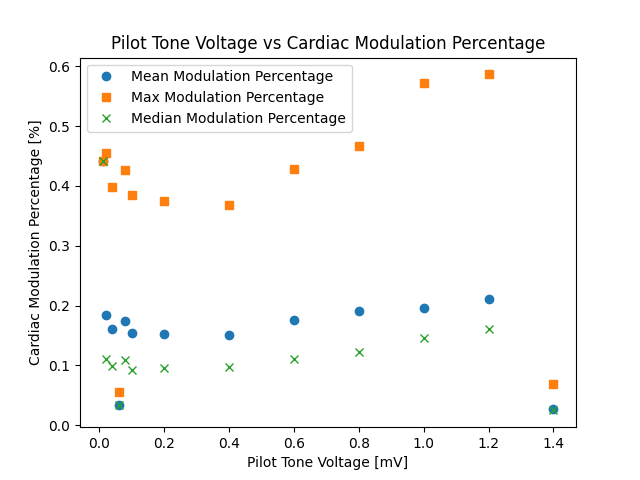

In [31]:
from pylottone.sobi import sobi
from pylottone.pt import pick_cardiac_source
# TODO: Apply more robust extraction techniques we learned from bss_methods and pilottone_extract_robust notebook.
npz_files = [f for f in os.listdir("/server/home/btasdelen/MRI_DATA/pilottone/vol0982_20240925/") if f.endswith(".npz")]
filt_bp_resp = designbp_tukeyfilt_freq(cfg['pilottone']['respiratory']['freq_start'], cfg['pilottone']['respiratory']['freq_stop'], f_samp, 17280)

filt_bp_cardiac = designbp_tukeyfilt_freq(cfg['pilottone']['cardiac']['freq_start'], 20, f_samp, 17280)

pt_wfs = {}
volts = []
mod_percentages  = []
for npz_file in npz_files:
    # print(f"Loading {npz_file}...")
    ids = "_".join(npz_file.split('_'))
    # print(f"IDs: {ids}")
    with np.load(os.path.join("/server/home/btasdelen/MRI_DATA/pilottone/vol0982_20240925/", npz_file)) as data:
        pt_wfs[ids] = {}
        for key in data.files:
            pt_wfs[ids][key] = data[key]

    pt_wfs[ids]['pt_raw_filt'] = savgol_filter(np.abs(pt_wfs[ids]['pt_raw']), 81, 3, axis=0)
    pt_wfs[ids]['pt_respiratory_freqs'] = apply_filter_freq(pt_wfs[ids]['pt_raw_filt'], filt_bp_resp, 'symmetric')
    pt_wfs[ids]['pt_cardiac_freqs'] = apply_filter_freq(pt_wfs[ids]['pt_raw_filt'], filt_bp_cardiac, 'symmetric')
    accept_list_cardiac,_,_ = pt.pickcoilsbycorr(pt_wfs[ids]['pt_cardiac_freqs'], 0, 0.8)
    print(f"Number or accepted coils: {len(accept_list_cardiac)}")
    pt_cardiac_sobi, Ucard, Vcard = sobi(pt_wfs[ids]['pt_cardiac_freqs'][:, accept_list_cardiac].T, num_lags=600)
    idxs, envstds = pick_cardiac_source(pt_cardiac_sobi.T, f_samp)
    sel_src = idxs[np.argmin(envstds)]
    pt_cardiac_bp = (Ucard[:,sel_src][:,None])@(pt_cardiac_sobi[sel_src,:][None,:])

    print(mrdhelper.get_volt_from_protoname(npz_file))
    volts.append(mrdhelper.get_volt_from_protoname(npz_file))
    pt_raw_sel = pt_wfs[ids]['pt_raw'][:,pt_wfs[ids]['accept_list_cardiac']]
    # mpcg = modulation_percentage(pt_wfs[ids]['S'][:,0], np.abs(pt_raw_sel[:,0]).mean(axis=0), mode='std')
    mpcg = modulation_percentage(pt_cardiac_bp.T, np.abs(pt_wfs[ids]['pt_raw'][:,accept_list_cardiac]).mean(axis=0), mode='std')

    print("Mean, max, median: ", np.mean(mpcg), np.max(mpcg), np.median(mpcg))
    mod_percentages.append(mpcg)


plt.figure()
plt.plot(volts, np.array([mp.mean() for mp in mod_percentages]), 'o', label='Mean Modulation Percentage')
plt.plot(volts, np.array([mp.max() for mp in mod_percentages]), 's', label='Max Modulation Percentage')
plt.plot(volts, np.array([np.median(mp) for mp in mod_percentages]), 'x', label='Median Modulation Percentage')
plt.legend()
plt.xlabel('Pilot Tone Voltage [mV]')
plt.ylabel('Cardiac Modulation Percentage [%]')
plt.title('Pilot Tone Voltage vs Cardiac Modulation Percentage')



/server/home/btasdelen/workspace/PyPilotTone/src/pylottone/vis.py:550: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f, axs = plt.subplots(1,1)


(<Figure size 1000x1000 with 1 Axes>,
 array([<Axes: xlabel='Time [s]'>], dtype=object))

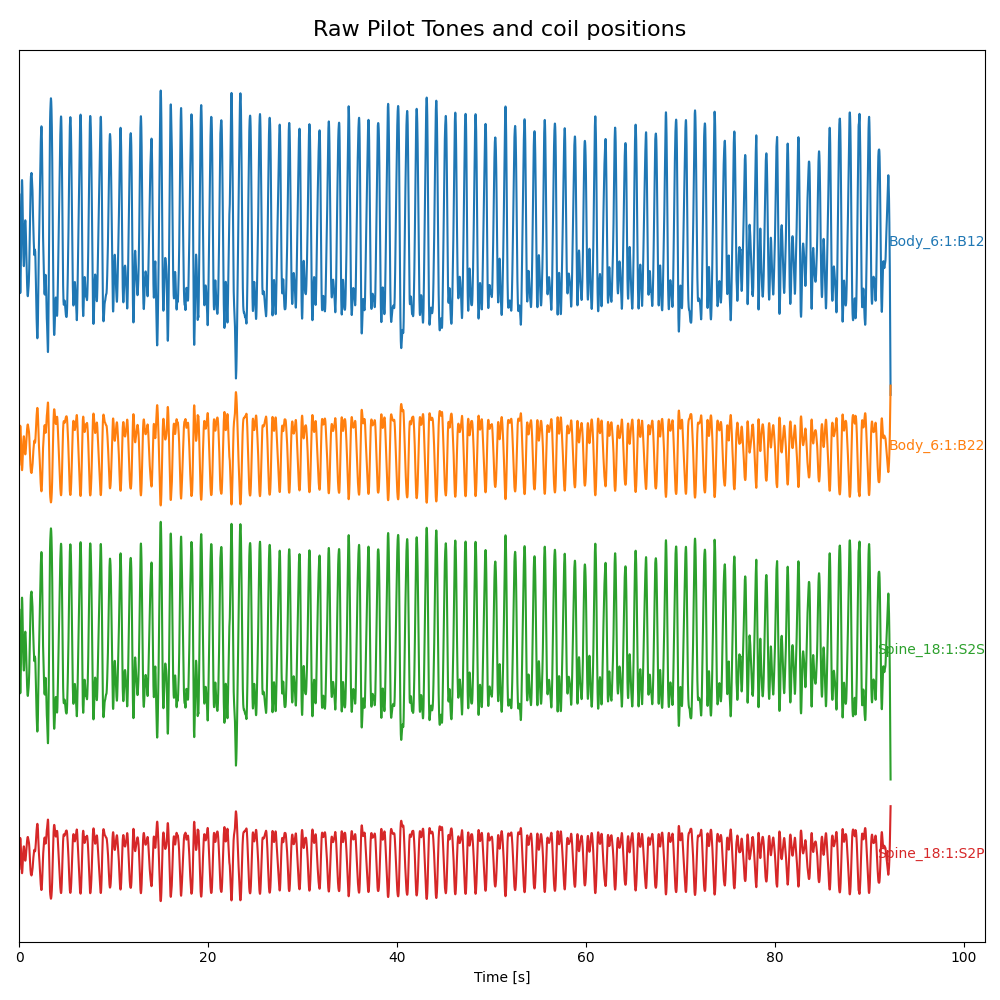

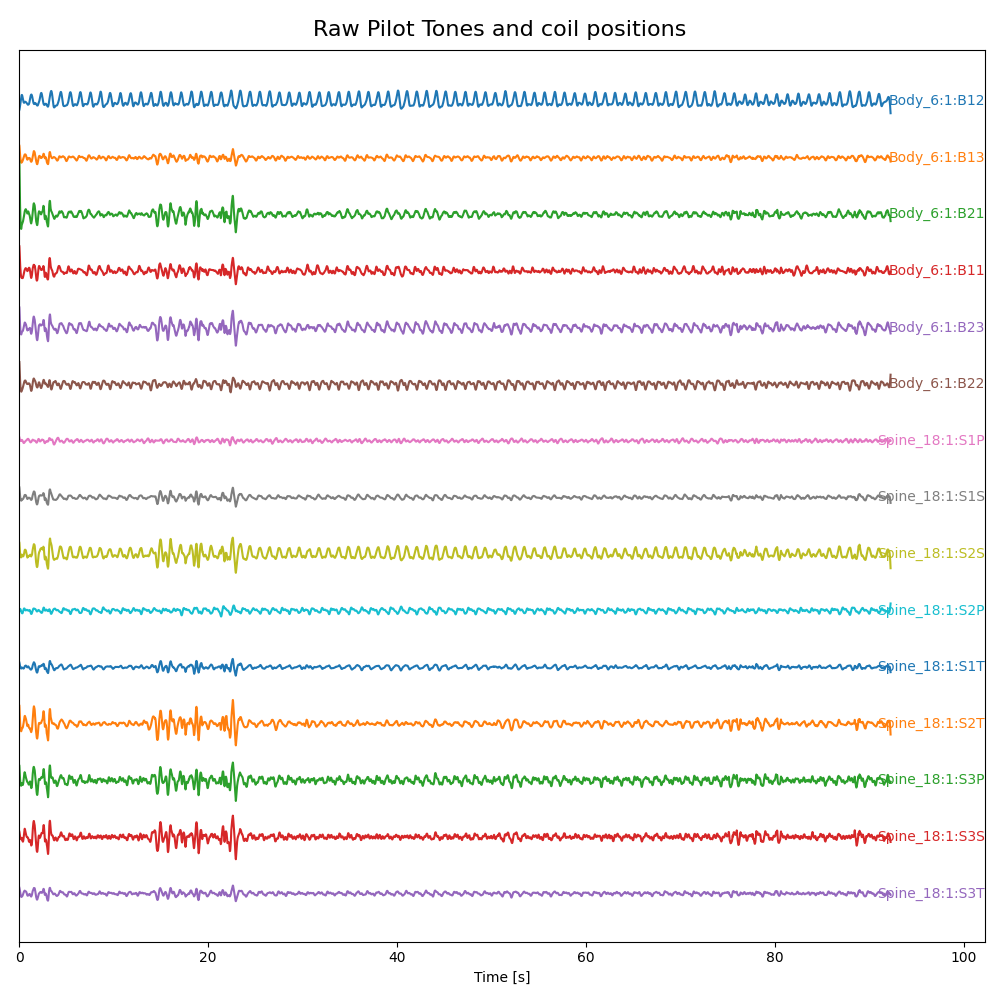

In [32]:
plot_rawpt(pt_cardiac_bp.T, coil_name[accept_list_cardiac], pt_wfs[ids]['time_pt'], sort=False, drawcoils=False)

plot_rawpt(pt_wfs[ids]['pt_cardiac_freqs'][:, :], coil_name[:], pt_wfs[ids]['time_pt'], sort=False, drawcoils=False)

In [78]:
# print(pt_wfs[ids]['coil_name'])
print(pt_wfs[ids]['accept_list_cardiac'])
print(pt_wfs[ids]['coil_name'][pt_wfs[ids]['accept_list_cardiac']])
print(pt_wfs[ids]['pt_raw'][:, pt_wfs[ids]['accept_list_cardiac']].shape)

[9 0 4 5 6 8]
['Spine_18:1:S3S' 'Body_6:1:B12' 'Body_6:1:B23' 'Body_6:1:B22'
 'Spine_18:1:S2S' 'Spine_18:1:S3P']
(17280, 6)


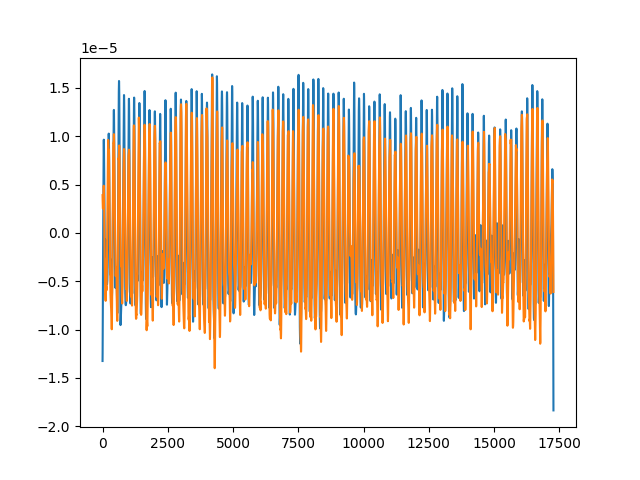

In [80]:

plt.figure()
plt.plot(pt_wfs[ids]['pt_cardiac_freqs'][:,0])
plt.plot(pt_wfs[ids]['S'][:,1])